In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import os

In [2]:
DATA_ROOT = r"C:\PCB_Project\module2_output\cropped_defects"  
IMAGE_DIM = 128
BATCH = 32
MAX_EPOCHS = 20
STOP_PATIENCE = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on:", device)

Running on: cpu


In [3]:
train_tfms = transforms.Compose([
    transforms.Resize((IMAGE_DIM, IMAGE_DIM)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_tfms = transforms.Compose([
    transforms.Resize((IMAGE_DIM, IMAGE_DIM)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [4]:
full_data = datasets.ImageFolder(DATA_ROOT)
labels = full_data.classes

train_len = int(0.8 * len(full_data))
val_len   = len(full_data) - train_len

train_data, val_data = random_split(full_data, [train_len, val_len])

train_data.dataset.transform = train_tfms
val_data.dataset.transform   = val_tfms

train_loader = DataLoader(train_data, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=BATCH)

In [5]:
network = models.efficientnet_b0(weights="IMAGENET1K_V1")

in_features = network.classifier[1].in_features
network.classifier[1] = nn.Linear(in_features, len(labels))

network = network.to(device)

In [6]:
loss_fn = nn.CrossEntropyLoss()

optimizer = optim.Adam(network.parameters(), lr=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=2,
    factor=0.2
)

In [7]:
best_val = float("inf")
patience_counter = 0

train_acc_log = []
val_acc_log   = []

for ep in range(MAX_EPOCHS):

    # ---- TRAIN ----
    network.train()
    correct_train = 0
    total_train = 0

    for imgs, labs in train_loader:
        imgs, labs = imgs.to(device), labs.to(device)

        optimizer.zero_grad()
        preds = network(imgs)
        loss = loss_fn(preds, labs)

        loss.backward()
        optimizer.step()

        _, predicted = torch.max(preds, 1)
        correct_train += (predicted == labs).sum().item()
        total_train += labs.size(0)

    train_acc = correct_train / total_train
    train_acc_log.append(train_acc)

    # ---- VALIDATION ----
    network.eval()
    correct_val = 0
    total_val = 0
    val_loss_sum = 0

    with torch.no_grad():
        for imgs, labs in val_loader:
            imgs, labs = imgs.to(device), labs.to(device)

            preds = network(imgs)
            loss = loss_fn(preds, labs)

            val_loss_sum += loss.item() * labs.size(0)

            _, predicted = torch.max(preds, 1)
            correct_val += (predicted == labs).sum().item()
            total_val += labs.size(0)

    val_acc = correct_val / total_val
    val_loss = val_loss_sum / total_val

    val_acc_log.append(val_acc)
    scheduler.step(val_loss)

    print(f"Epoch {ep+1}: Train Accuracy={train_acc:.3f}  Val Accuracy={val_acc:.3f}")

    # ---- EARLY STOPPING ----
    if val_loss < best_val:
        best_val = val_loss
        torch.save(network.state_dict(), "pcb_defect_model.pth")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= STOP_PATIENCE:
            print("Stopping early")
            break

Epoch 1: Train Accuracy=0.817  Val Accuracy=0.959
Epoch 2: Train Accuracy=0.955  Val Accuracy=0.975
Epoch 3: Train Accuracy=0.979  Val Accuracy=0.977
Epoch 4: Train Accuracy=0.983  Val Accuracy=0.981
Epoch 5: Train Accuracy=0.985  Val Accuracy=0.985
Epoch 6: Train Accuracy=0.990  Val Accuracy=0.982
Epoch 7: Train Accuracy=0.991  Val Accuracy=0.988
Epoch 8: Train Accuracy=0.990  Val Accuracy=0.987
Epoch 9: Train Accuracy=0.990  Val Accuracy=0.987
Epoch 10: Train Accuracy=0.992  Val Accuracy=0.988
Epoch 11: Train Accuracy=0.993  Val Accuracy=0.987
Epoch 12: Train Accuracy=0.991  Val Accuracy=0.983
Epoch 13: Train Accuracy=0.993  Val Accuracy=0.983
Stopping early


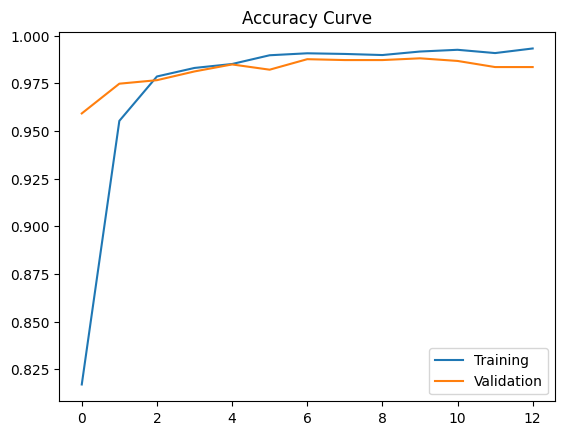

In [8]:
plt.plot(train_acc_log, label="Training")
plt.plot(val_acc_log, label="Validation")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [9]:
y_true = []
y_pred = []

network.eval()

with torch.no_grad():
    for imgs, labs in val_loader:
        imgs = imgs.to(device)
        outputs = network(imgs)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labs.numpy())
        y_pred.extend(preds.cpu().numpy())

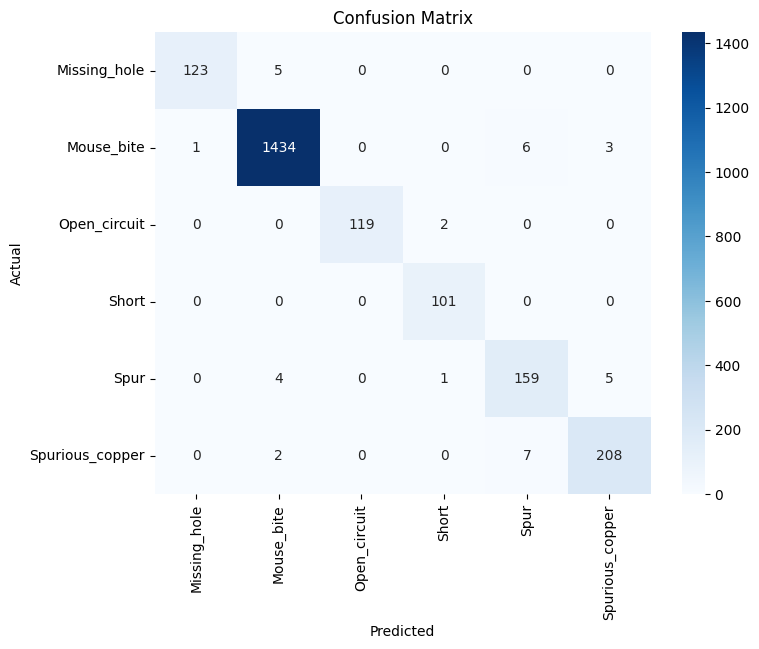

In [10]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [11]:
print(classification_report(y_true, y_pred, target_names=labels))

                 precision    recall  f1-score   support

   Missing_hole       0.99      0.96      0.98       128
     Mouse_bite       0.99      0.99      0.99      1444
   Open_circuit       1.00      0.98      0.99       121
          Short       0.97      1.00      0.99       101
           Spur       0.92      0.94      0.93       169
Spurious_copper       0.96      0.96      0.96       217

       accuracy                           0.98      2180
      macro avg       0.97      0.97      0.97      2180
   weighted avg       0.98      0.98      0.98      2180



In [14]:
torch.save(network.state_dict(), "pcb_defect_model.pth")

In [13]:
torch.save({
    "model_state": network.state_dict(),
    "classes": labels,
}, "pcb_defect_model.pth")

In [16]:
torch.save({
    "model_state": network.state_dict(),
    "num_classes": len(labels),
    "class_names": labels
}, "pcb_final_model.pth")